## Importing the libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')
pd.set_option('display.max_columns',None)

In [4]:
master_table = pd.read_pickle('master_table.pkl')

In [5]:
master_table.shape

(119143, 57)

In [6]:
master_table.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 57 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   customer_unique_id             119143 non-null  object        
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-null  object        
 11  

In [7]:
master_table.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                   177
order_delivered_carrier_date       2086
order_delivered_customer_date      3421
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
order_item_id                       833
product_id                          833
seller_id                           833
shipping_limit_date                 833
price                               833
freight_value                       833
product_category_name              2542
product_name_lenght                2542
product_description_lenght         2542
product_photos_qty                 2542
product_weight_g                    853
product_length_cm                   853
product_height_cm                   853


### Analysis 1: Monthly sales analysis

In [8]:
monthly_sales = (master_table.groupby(['purchase_year','purchase_month'])['payment_value'].sum().reset_index())
monthly_sales['year_month'] = (monthly_sales['purchase_year'].astype(str) + '-' + monthly_sales['purchase_month'].astype(str).str.zfill(2))

In [9]:
# Removing the incomplete month
monthly_sales = monthly_sales[~((monthly_sales['purchase_year']==2018) & (monthly_sales['purchase_month'].isin([9,10])))]

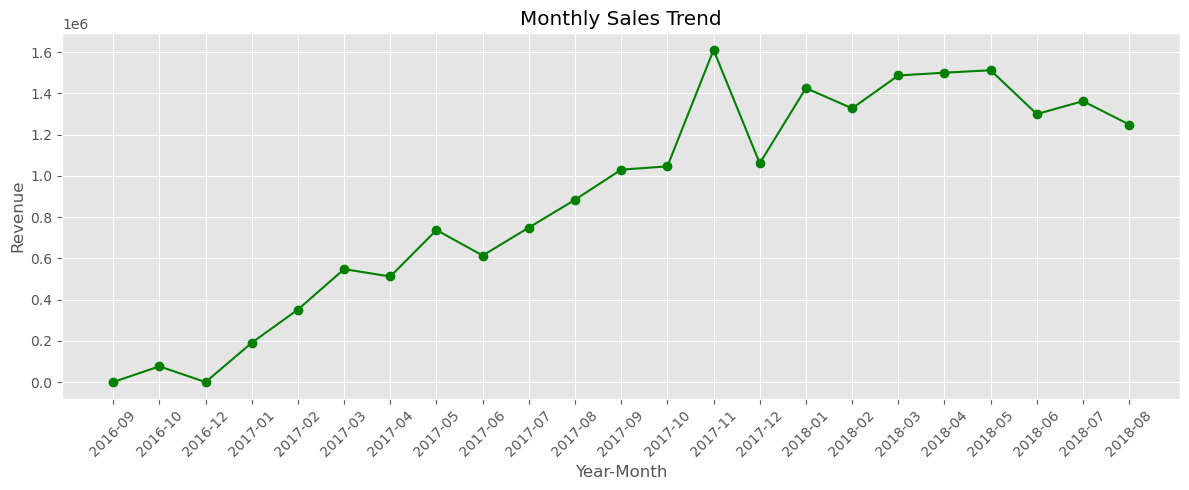

In [10]:
plt.figure(figsize = (12,5))
plt.plot(monthly_sales['year_month'],monthly_sales['payment_value'],marker='o',color='green')
plt.xticks(rotation=45)
plt.title('Monthly Sales Trend')
plt.xlabel('Year-Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

### Busines Insights

### Analysis 2: Top product Categories by Revenue

In [11]:
category_sales = (master_table.groupby('product_category_name_english')['payment_value'].sum().sort_values(ascending = False).head(10))
category_sales

product_category_name_english
bed_bath_table           1743998.80
health_beauty            1662963.59
computers_accessories    1599481.06
furniture_decor          1443963.61
watches_gifts            1430553.48
sports_leisure           1400223.07
housewares               1097900.09
auto                      855095.68
garden_tools              840721.59
cool_stuff                781933.97
Name: payment_value, dtype: float64

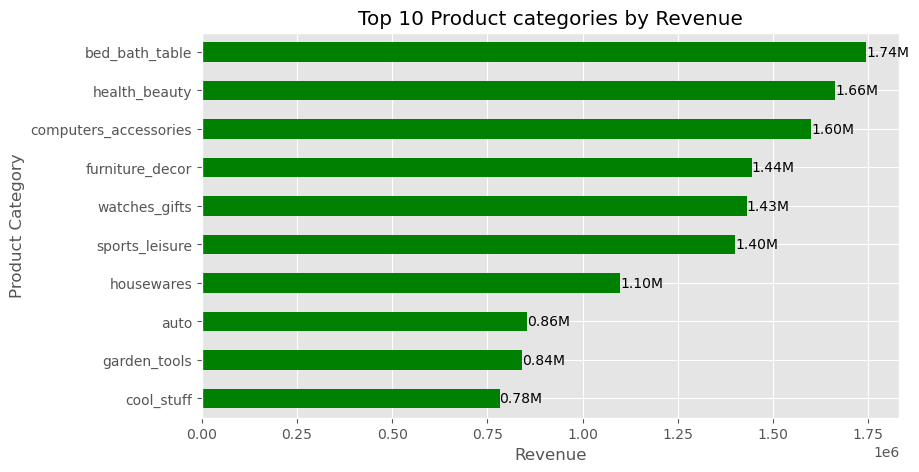

In [12]:
plt.figure(figsize =(9,5))
category_sales.sort_values().plot(kind='barh',color='green')
plt.title('Top 10 Product categories by Revenue')
plt.xlabel('Revenue')
plt.ylabel('Product Category')

for index,value in enumerate(category_sales.sort_values()):
    plt.text(value,index, f'{value/1e6:.2f}M',va='center')
plt.show()

#### Business Insights

### Analysis 3: Top product category by number of orders

In [13]:
top_products = master_table.groupby('product_category_name_english')['order_id'].count().sort_values(ascending=False).head(10)

In [14]:
top_products

product_category_name_english
bed_bath_table           11988
health_beauty            10032
sports_leisure            9004
furniture_decor           8832
computers_accessories     8150
housewares                7380
watches_gifts             6213
telephony                 4726
garden_tools              4590
auto                      4400
Name: order_id, dtype: int64

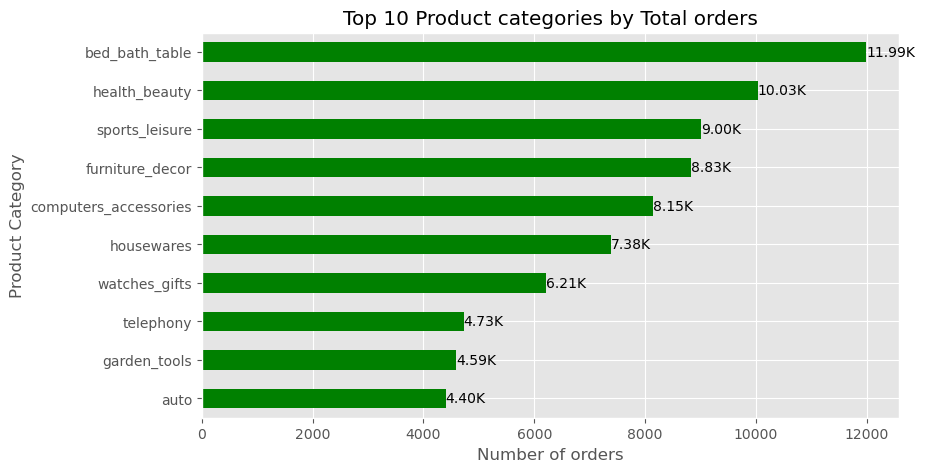

In [15]:
plt.figure(figsize =(9,5))
top_products.sort_values().plot(kind='barh',color='green')
plt.title('Top 10 Product categories by Total orders')
plt.xlabel('Number of orders')
plt.ylabel('Product Category')

for index,value in enumerate(top_products.sort_values()):
    plt.text(value,index, f'{value/1000:.2f}K',va='center')
    
plt.show()

### Analysis 4: Top states by Revenue

In [16]:
top_states = master_table.groupby('customer_state')['payment_value'].count().sort_values(ascending=False).head(10)
top_states

customer_state
SP    50262
RJ    15518
MG    13819
RS     6573
PR     6043
SC     4345
BA     4091
DF     2516
GO     2466
ES     2360
Name: payment_value, dtype: int64

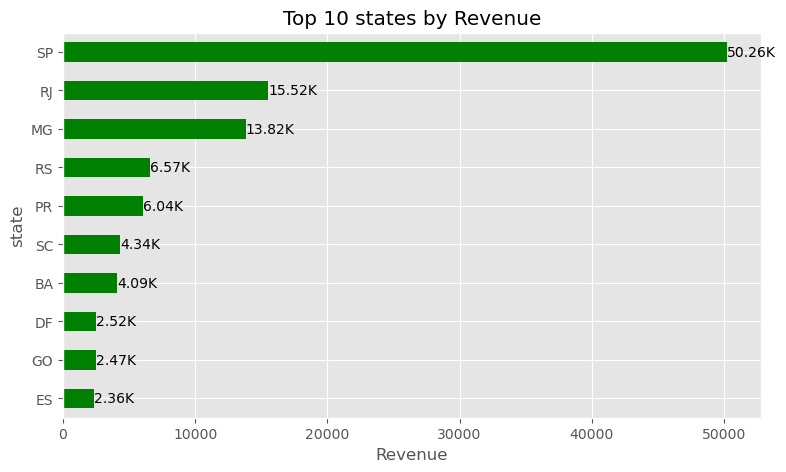

In [17]:
plt.figure(figsize =(9,5))
top_states.sort_values().plot(kind='barh',color='green')
plt.title('Top 10 states by Revenue')
plt.xlabel('Revenue')
plt.ylabel('state')

for index,value in enumerate(top_states.sort_values()):
    plt.text(value,index, f'{value/1000:.2f}K',va='center')

plt.show()

### Analysis 4: Top city by Revenue

In [18]:
top_city = master_table.groupby('customer_city')['payment_value'].count().sort_values(ascending=False).head(10)
top_city

customer_city
sao paulo                18875
rio de janeiro            8311
belo horizonte            3299
brasilia                  2500
curitiba                  1827
campinas                  1757
porto alegre              1675
salvador                  1544
guarulhos                 1415
sao bernardo do campo     1131
Name: payment_value, dtype: int64

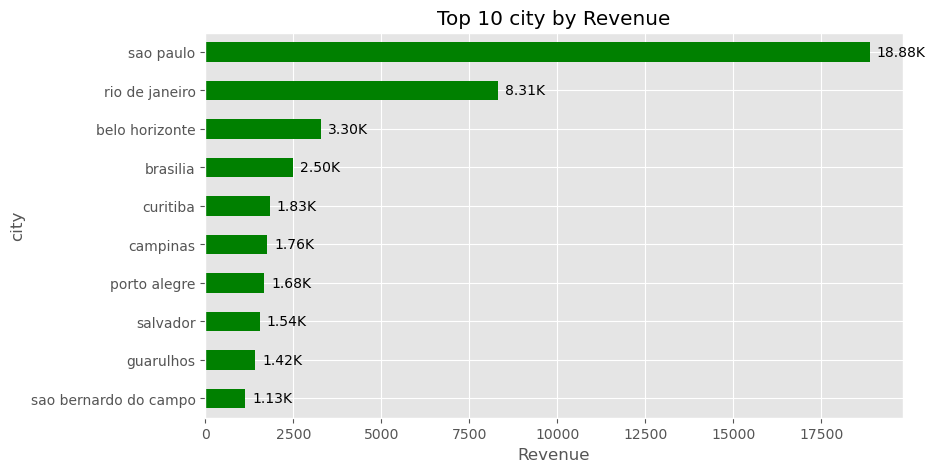

In [19]:
plt.figure(figsize =(9,5))
top_city.sort_values().plot(kind='barh',color='green')
plt.title('Top 10 city by Revenue')
plt.xlabel('Revenue')
plt.ylabel('city')

for index,value in enumerate(top_city.sort_values()):
    plt.text(value+200,index, f'{value/1000:.2f}K',va='center')
plt.show()

### Analysis 5: Revenue by Payment Type

In [31]:
revenue_payment = master_table.groupby('payment_type')['payment_value'].sum().sort_values()
revenue_payment

payment_type
not_defined           0.00
debit_card       257374.89
voucher          435917.84
boleto          4110920.74
credit_card    15775450.54
Name: payment_value, dtype: float64

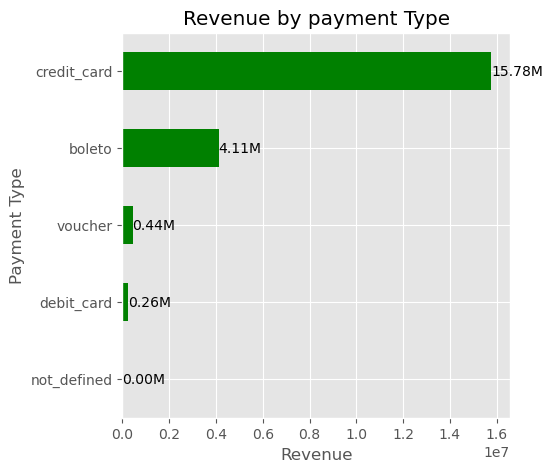

In [32]:
plt.figure(figsize=(5,5))
revenue_payment.plot(kind='barh',color='green')
plt.title('Revenue by payment Type')
plt.xlabel('Revenue')
plt.ylabel('Payment Type')

for i,value in enumerate(revenue_payment):
    plt.text(value+200,i, f'{value/1e6:.2f}M',va='center')

plt.show() 

#### Business Insights

### Analysis 6: Review Score Distribution

In [24]:
review_distribution = master_table['review_score'].value_counts().sort_index()
review_distribution

review_score
1.0    15428
2.0     4162
3.0     9894
4.0    22319
5.0    66343
Name: count, dtype: int64

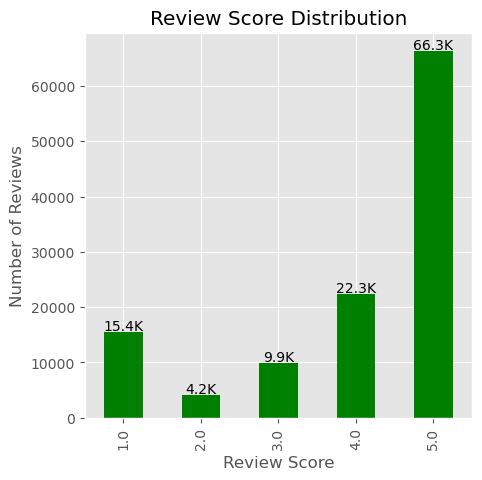

In [25]:
plt.figure(figsize=(5,5))
review_distribution.plot(kind='bar',color='green')
plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Reviews')

for i,value in enumerate(review_distribution):
    plt.text(i,value+300,f'{value/1000:.1f}K',ha='center')
    
plt.show()

#### Business Insights

### Analysis 7: Revenue by Weekday vs Weekend

In [34]:
weekday_revenue = (master_table.groupby('is_weekend')['payment_value'].sum())
weekday_revenue.index = ['weekday','weekend']
weekday_revenue

weekday    16109602.91
weekend     4470061.10
Name: payment_value, dtype: float64

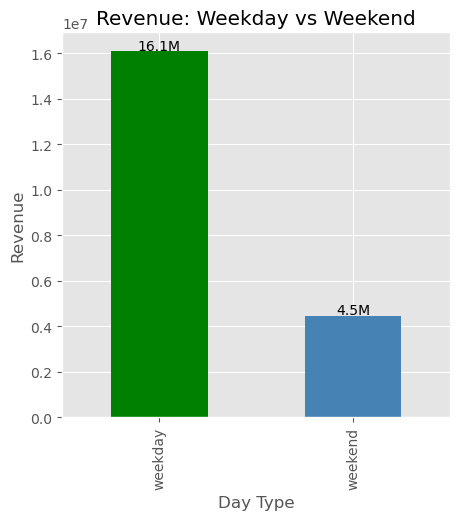

In [38]:
plt.figure(figsize=(5,5))
weekday_revenue.plot(kind='bar',color=['green','steelblue'])
plt.title('Revenue: Weekday vs Weekend')
plt.xlabel('Day Type')
plt.ylabel('Revenue')

for i,value in enumerate(weekday_revenue):
    plt.text(i,value+50000,f'{value/1e6:.1f}M',ha='center')
    
plt.show()

#### Business Insights

### Analysis 8: Revenue by Quarter

In [41]:
quarter_revenue = (master_table.groupby('purchase_quarter')['payment_value'].sum().sort_index().sort_values(ascending=False))
quarter_revenue

purchase_quarter
2    6175396.28
1    5329894.25
3    5279590.89
4    3794782.59
Name: payment_value, dtype: float64

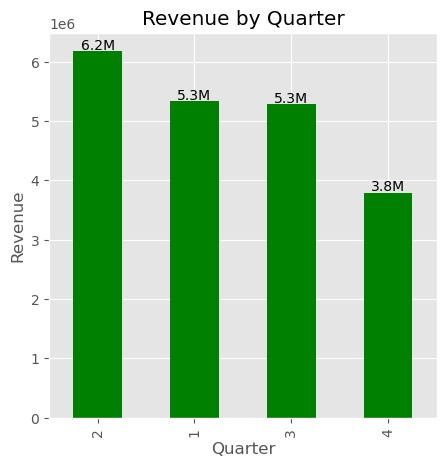

In [45]:
plt.figure(figsize=(5,5))
quarter_revenue.plot(kind='bar',color='green')
plt.title('Revenue by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Revenue')

for i,value in enumerate(quarter_revenue):
    plt.text(i,value+30000,f'{value/1e6:.1f}M',ha='center')
    
plt.show()

#### Business insights

### Analysis 9: Delivery Performance

In [49]:
avg_delivery = master_table['delivery_days'].mean()
print(f'Average Delivery time: {avg_delivery:.2f} days')

Average Delivery time: 12.02 days


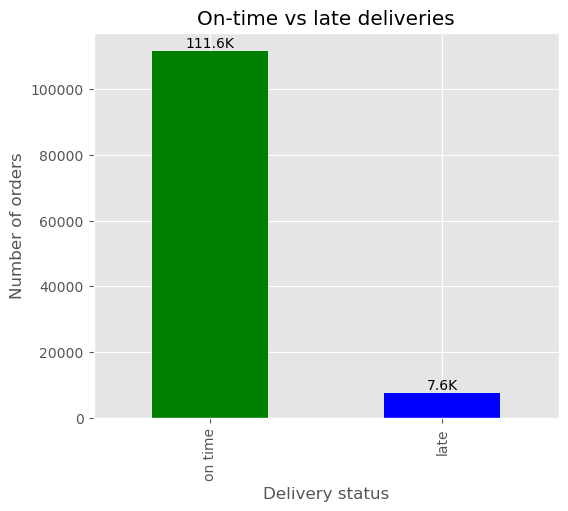

In [53]:
delivery_status= master_table['is_late_delivery'].value_counts()
delivery_status.index = ['on time','late']

plt.figure(figsize=(6,5))
delivery_status.plot(kind='bar',color=['green','blue'])
plt.title('On-time vs late deliveries')
plt.xlabel('Delivery status')
plt.ylabel('Number of orders')

for i,value in enumerate(delivery_status):
    plt.text(i,value+1000,f'{value/1000:.1f}K',ha='center')
    
plt.show()

### Analysis 10: correlation

In [56]:
corr = master_table[['payment_value','price','freight_value','delivery_days','review_score']].corr()
corr

,payment_value,price,freight_value,delivery_days,review_score
payment_value,1.000000,0.739236,0.373762,0.060449,-0.082343
price,0.739236,1.000000,0.415938,0.061389,-0.004492
freight_value,0.373762,0.415938,1.000000,0.212870,-0.037013
delivery_days,0.060449,0.061389,0.212870,1.000000,-0.302750
review_score,-0.082343,-0.004492,-0.037013,-0.302750,1.000000


<function matplotlib.pyplot.show(close=None, block=None)>

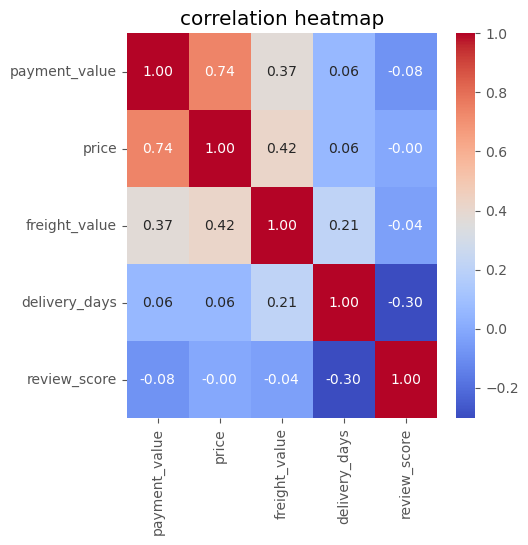

In [59]:
plt.figure(figsize=(5,5))
sns.heatmap(corr,annot=True,cmap='coolwarm',fmt='.2f')
plt.title('correlation heatmap')
plt.show

#### Business insights